In [1]:
import os, sys, random, warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

sys.path.insert(0, "..")
from src.forecasting_utils import (
    chronological_split, all_metrics,
    TRAIN_END, VAL_END, TEST_END,
)

# Reproducibility
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
warnings.filterwarnings("ignore")
print("TensorFlow:", tf.__version__)

TensorFlow: 2.16.2


In [2]:
df = pd.read_parquet("../data/processed/subsample_features.parquet")

LSTM_FEATURES = [
    "lag_7", "lag_14", "lag_28",
    "rolling_mean_7", "rolling_mean_28", "rolling_std_7",
    "day_of_week", "week_of_year", "month", "is_weekend",
    "days_since_last_event", "days_to_next_event",
    "is_snap_day", "is_sporting_event", "is_cultural_event",
    "is_national_event", "is_religious_event",
    "sell_price", "price_change",
]
TARGET = "sales"
SEQ_LEN = 28   # Methodology §3.6.1: 28-day lookback

# Drop the warm-up rows with NaN lag/rolling features
df = df.dropna(subset=LSTM_FEATURES + [TARGET]).sort_values(["id", "date"]).reset_index(drop=True)
print(f"Series: {df['id'].nunique()}  | rows: {len(df):,}  | features: {len(LSTM_FEATURES)}")

Series: 502  | rows: 932,716  | features: 19


In [3]:
def make_sequences(df, features, target, seq_len):
    """For each series, build (X, y, id, target_date) where X is the past seq_len days."""
    Xs, ys, ids, dates = [], [], [], []
    for sid, grp in df.groupby("id", sort=False):
        if len(grp) <= seq_len:
            continue
        X_arr = grp[features].to_numpy(dtype=np.float32)
        y_arr = grp[target].to_numpy(dtype=np.float32)
        d_arr = grp["date"].to_numpy()
        for i in range(len(grp) - seq_len):
            Xs.append(X_arr[i:i+seq_len])
            ys.append(y_arr[i+seq_len])
            ids.append(sid)
            dates.append(d_arr[i+seq_len])
    return (
        np.stack(Xs).astype(np.float32),
        np.asarray(ys, dtype=np.float32),
        np.asarray(ids),
        np.asarray(dates, dtype="datetime64[ns]"),
    )

print("Building sequences... (this can take 3-5 min)")
X_all, y_all, id_all, date_all = make_sequences(df, LSTM_FEATURES, TARGET, SEQ_LEN)
print(f"Total sequences: {X_all.shape}, targets: {y_all.shape}")

Building sequences... (this can take 3-5 min)
Total sequences: (918660, 28, 19), targets: (918660,)


In [9]:
train_end_np = np.datetime64(TRAIN_END)
val_end_np   = np.datetime64(VAL_END)
test_end_np  = np.datetime64(TEST_END)

train_mask = date_all <= train_end_np
val_mask   = (date_all > train_end_np) & (date_all <= val_end_np)
test_mask  = (date_all > val_end_np)   & (date_all <= test_end_np)

X_train, y_train = X_all[train_mask], y_all[train_mask]
X_val,   y_val   = X_all[val_mask],   y_all[val_mask]
X_test,  y_test  = X_all[test_mask],  y_all[test_mask]

print(f"Train sequences: {X_train.shape}")
print(f"Val sequences  : {X_val.shape}")
print(f"Test sequences : {X_test.shape}")

# Scale features (fit on train, transform all)
n_feats = X_train.shape[2]
feat_scaler = MinMaxScaler()
feat_scaler.fit(X_train.reshape(-1, n_feats))

def scale_X(X):
    n = X.shape[0]
    return feat_scaler.transform(X.reshape(-1, n_feats)).reshape(n, SEQ_LEN, n_feats).astype(np.float32)

X_train_s = scale_X(X_train)
X_val_s   = scale_X(X_val)
X_test_s  = scale_X(X_test)

# Scale target
# Log1p transform on target — robust to zero-heavy intermittent demand
y_train_t = np.log1p(y_train).astype(np.float32)
y_val_t   = np.log1p(y_val).astype(np.float32)
print(f"y_train range (log space): [{y_train_t.min():.2f}, {y_train_t.max():.2f}]")

print("Scaling done.")

Train sequences: (860930, 28, 19)
Val sequences  : (30120, 28, 19)
Test sequences : (27610, 28, 19)
y_train range (log space): [0.00, 5.26]
Scaling done.


In [10]:
tf.keras.backend.clear_session()
tf.random.set_seed(SEED)

model = Sequential([
    Input(shape=(SEQ_LEN, n_feats)),
    LSTM(128, return_sequences=True),   # stacked layer 1
    Dropout(0.2),
    LSTM(64),                            # stacked layer 2
    Dropout(0.2),
    Dense(1),
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
    metrics=["mae"],
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 28, 128)        │        75,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 28, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 125,249 (489.25 KB)

 Trainable params: 125,249 (489.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
3364/3364 ━━━━━━━━━━━━━━━━━━━━ 60s 18ms/step - loss: 0.1959 - mae: 0.2998 - val_loss: 0.2346 - val_mae: 0.3487
Epoch 2/50
3364/3364 ━━━━━━━━━━━━━━━━━━━━ 59s 17ms/step - loss: 0.1880 - mae: 0.2882 - val_loss: 0.2360 - val_mae: 0.3404
Epoch 3/50
3364/3364 ━━━━━━━━━━━━━━━━━━━━ 59s 17ms/step - loss: 0.1868 - mae: 0.2868 - val_loss: 0.2348 - val_mae: 0.3406
Epoch 4/50
3364/3364 ━━━━━━━━━━━━━━━━━━━━ 59s 17ms/step - loss: 0.1861 - mae: 0.2861 - val_loss: 0.2334 - val_mae: 0.3398
Epoch 5/50
3364/3364 ━━━━━━━━━━━━━━━━━━━━ 59s 17ms/step - loss: 0.1855 - mae: 0.2859 - val_loss: 0.2313 - val_mae: 0.3445
Epoch 6/50
3364/3364 ━━━━━━━━━━━━━━━━━━━━ 63s 19ms/step - loss: 0.1847 - mae: 0.2853 - val_loss: 0.2304 - val_mae: 0.3436
Epoch 7/50
3364/3364 ━━━━━━━━━━━━━━━━━━━━ 69s 21ms/step - loss: 0.1840 - mae: 0.2845 - val_loss: 0.2299 - val_mae: 0.3431
Epoch 8/50
3364/3364 ━━━━━━━━━━━━━━━━━━━━ 66s 20ms/step - loss: 0.1834 - mae: 0.2840 - val_loss: 0.2288 - val_mae: 0.3456
Epoch 9/50
3364/3364 ━━━

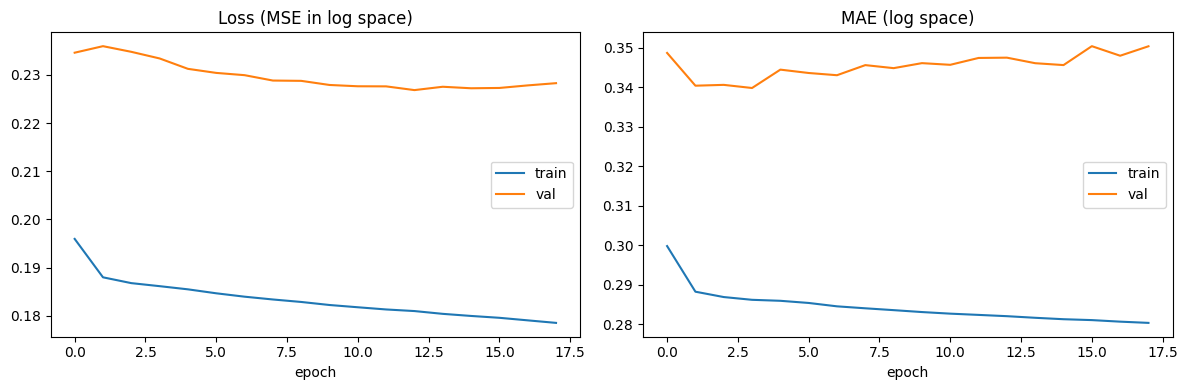

In [11]:
es = EarlyStopping(
    monitor="val_loss", patience=5,
    restore_best_weights=True, verbose=1,
)

history = model.fit(
    X_train_s, y_train_t,                    # ← was y_train_s
    validation_data=(X_val_s, y_val_t),       # ← was y_val_s
    epochs=50,
    batch_size=256,
    callbacks=[es],
    verbose=1,
)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history.history["loss"], label="train"); ax[0].plot(history.history["val_loss"], label="val")
ax[0].set_title("Loss (MSE in log space)"); ax[0].set_xlabel("epoch"); ax[0].legend()
ax[1].plot(history.history["mae"], label="train"); ax[1].plot(history.history["val_mae"], label="val")
ax[1].set_title("MAE (log space)"); ax[1].set_xlabel("epoch"); ax[1].legend()
plt.tight_layout(); plt.show()

In [12]:
# Predict in log space, then inverse-transform with expm1
y_pred_log = model.predict(X_test_s, batch_size=512, verbose=1).flatten()
y_pred = np.clip(np.expm1(y_pred_log), 0, None)   # back to sales units

metrics = all_metrics(y_test, y_pred, "LSTM")
print(metrics)

54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
{'model': 'LSTM', 'MAE': 1.208859920501709, 'RMSE': 2.3635196685791016, 'MAPE_pct': 58.49377540378475, 'WMAPE_pct': 93.4029752625679, 'Pred10_pct': 7.786639224766315}


In [13]:
model.save("../models/lstm_model.keras")

test_preds_lstm = pd.DataFrame({
    "id":     id_all[test_mask],
    "date":   date_all[test_mask],
    "y_true": y_test,
    "pred_lstm": y_pred,
})
test_preds_lstm.to_parquet("../artifacts/lstm_test_predictions.parquet", index=False)

y_val_pred_log = model.predict(X_val_s, batch_size=512, verbose=0).flatten()
y_val_pred = np.clip(np.expm1(y_val_pred_log), 0, None)
val_preds_lstm = pd.DataFrame({
    "id":     id_all[val_mask],
    "date":   date_all[val_mask],
    "y_true": y_val,
    "pred_lstm": y_val_pred,
})
val_preds_lstm.to_parquet("../artifacts/lstm_val_predictions.parquet", index=False)

# Update consolidated results (overwrite the bad LSTM row)
ml_results = pd.read_csv("../data/processed/ml_model_results.csv")
ml_results = ml_results[ml_results["model"] != "LSTM"]      # drop the old bad row
ml_results = pd.concat([ml_results, pd.DataFrame([metrics])], ignore_index=True)
ml_results.to_csv("../data/processed/ml_model_results.csv", index=False)
display(ml_results.sort_values("MAE"))

,model,MAE,RMSE,MAPE_pct,WMAPE_pct,Pred10_pct
1,XGBoost,0.970340,1.931625,53.150087,74.973658,9.355973
0,LightGBM,0.976350,1.952907,53.663774,75.438034,9.218763
2,RandomForest,0.977026,1.879122,55.597250,75.490264,9.870509
3,LSTM,1.208860,2.363520,58.493775,93.402975,7.786639
